# Índice

- [Modelos](#modelos)
- [Definición del circuito](#definición-del_circuito)
- [Resultados](#resultados)

In [1]:
import jax.numpy as jnp
import sax
import sax.models as sm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
color = cm.rainbow(np.linspace(0, 1, 10))


# Modelos

In [3]:
#Definimos un modelo de guía dispersiva con los datos obtenidos en las simulaciones
wls_neff = jnp.linspace(1.5, 1.6, 200)

neffs = jnp.asarray([
    1.52234795, 1.52218737, 1.52202688, 1.52186647, 1.52170615,
    1.52154592, 1.52138578, 1.52122573, 1.52106577, 1.52090589,
    1.5207461, 1.52058641, 1.5204268, 1.52026728, 1.52010785,
    1.51994851, 1.51978926, 1.5196301, 1.51947103, 1.51931205,
    1.51915316, 1.51899437, 1.51883566, 1.51867704, 1.51851851,
    1.51836007, 1.51820172, 1.51804347, 1.5178853, 1.51772723,
    1.51756924, 1.51741135, 1.51725355, 1.51709584, 1.51693823,
    1.5167807, 1.51662327, 1.51646593, 1.51630868, 1.51615152,
    1.51599445, 1.51583748, 1.5156806, 1.51552382, 1.51536712,
    1.51521052, 1.51505401, 1.5148976, 1.51474128, 1.51458505,
    1.51442891, 1.51427287, 1.51411693, 1.51396107, 1.51380531,
    1.51364965, 1.51349408, 1.5133386, 1.51318322, 1.51302793,
    1.51287274, 1.51271764, 1.51256264, 1.51240773, 1.51225292,
    1.5120982, 1.51194358, 1.51178905, 1.51163462, 1.51148028,
    1.51132605, 1.5111719, 1.51101785, 1.5108639, 1.51071005,
    1.51055629, 1.51040263, 1.51024906, 1.5100956, 1.50994222,
    1.50978895, 1.50963577, 1.50948269, 1.50932971, 1.50917683,
    1.50902404, 1.50887135, 1.50871876, 1.50856626, 1.50841387,
    1.50826157, 1.50810937, 1.50795727, 1.50780527, 1.50765337,
    1.50750156, 1.50734986, 1.50719825, 1.50704674, 1.50689534,
    1.50674403, 1.50659282, 1.50644171, 1.5062907, 1.50613979,
    1.50598898, 1.50583827, 1.50568766, 1.50553715, 1.50538674,
    1.50523643, 1.50508623, 1.50493612, 1.50478612, 1.50463621,
    1.50448641, 1.50433671, 1.50418711, 1.50403761, 1.50388821,
    1.50373891, 1.50358972, 1.50344063, 1.50329164, 1.50314275,
    1.50299397, 1.50284528, 1.50269671, 1.50254823, 1.50239985,
    1.50225158, 1.50210341, 1.50195535, 1.50180739, 1.50165953,
    1.50151178, 1.50136412, 1.50121658, 1.50106913, 1.50092179,
    1.50077456, 1.50062743, 1.5004804, 1.50033348, 1.50018666,
    1.50003995, 1.49989334, 1.49974684, 1.49960044, 1.49945415,
    1.49930796, 1.49916188, 1.49901591, 1.49887004, 1.49872427,
    1.49857861, 1.49843306, 1.49828761, 1.49814227, 1.49799704,
    1.49785191, 1.49770689, 1.49756198, 1.49741717, 1.49727247,
    1.49712788, 1.49698339, 1.49683901, 1.49669474, 1.49655058,
    1.49640652, 1.49626258, 1.49611874, 1.495975, 1.49583138,
    1.49568786, 1.49554446, 1.49540116, 1.49525797, 1.49511489,
    1.49497191, 1.49482905, 1.4946863, 1.49454365, 1.49440111,
    1.49425869, 1.49411637, 1.49397416, 1.49383207, 1.49369008,
    1.4935482, 1.49340643, 1.49326478, 1.49312323, 1.49298179,
    1.49284047, 1.49269925, 1.49255815, 1.49241715, 1.49227627,
])


def interp_neff(wl=1.55):
    """
    Interpola neff(wl) siguiendo el ejemplo oficial de SAX:
    se interpola frente a 1 / wl, no directamente frente a wl.

    wl en micras.
    """
    wl = jnp.asarray(wl)

    return jnp.interp(
        1 / wl,
        1 / wls_neff[::-1],
        neffs[::-1],
    )

def wg_disp(
    *,
    wl=1.55,
    length=10.0,
    loss=0.0,
):
    neff = interp_neff(wl)
    phase = 2 * jnp.pi * neff * length / wl
    amplitude = 10 ** (-loss * length / 20)
    transmission = amplitude * jnp.exp(1j * phase)

    return sax.reciprocal({
        ("in0", "out0"): transmission,
    })

def coupler(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi2x2(coupling=0.95) -> sax.SDict: 
    kappa = coupling**0.5
    tau = (1 - coupling) ** 0.5
    coupler_dict = sax.reciprocal(
        {
            ("in0", "out0"): tau,
            ("in0", "out1"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out0"): kappa * np.exp(-1j * np.pi / 2.0),
            ("in1", "out1"): tau,
        }
    )
    return coupler_dict

def mmi3x3() -> sax.SDict:
    coup = jnp.sqrt(1/3)
    mmi_dict = sax.reciprocal(
        {
            ("in0", "out0"): coup*jnp.exp( 1j* 2*jnp.pi /3),
            ("in0", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in0", "out2"): coup,

            ("in1", "out0"): coup*jnp.exp(-1j*jnp.pi /3),
            ("in1", "out1"): coup,
            ("in1", "out2"): coup*jnp.exp( -1j*jnp.pi /3),

            ("in2", "out0"): coup,
            ("in2", "out1"): coup*jnp.exp( -1j*jnp.pi /3),
            ("in2", "out2"): coup*jnp.exp( 1j* 2*jnp.pi /3),

        }
    )

    return mmi_dict

# Definición del circuito

In [4]:

wvltracker, info = sax.circuit(
    netlist={
        "instances": {
            "mmi2x2": "mmi2x2",
            "wvg_u": "wg_disp",
            "wvg_d": "wg_disp",
            "mmi3x3": "mmi3x3",
        },
        "connections": {
            "mmi2x2,out0": "wvg_u,in0",
            "wvg_u,out0": "mmi3x3,in0",
            "mmi2x2,out1": "wvg_d,in0",
            "wvg_d,out0": "mmi3x3,in2",
        },
        "ports": {
            "in0": "mmi2x2,in0",
            "in1": "mmi2x2,in1",
            "out0": "mmi3x3,out0",
            "out1": "mmi3x3,out1",
            "out2": "mmi3x3,out2",
        },
    },
    models={
        "mmi2x2": mmi2x2,
        "wg_disp":wg_disp,
        "mmi3x3" : mmi3x3,
    },
)


## Resultados

<>:27: SyntaxWarning: invalid escape sequence '\D'
<>:27: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_36253/1047063776.py:27: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta \lambda$ (pm)")


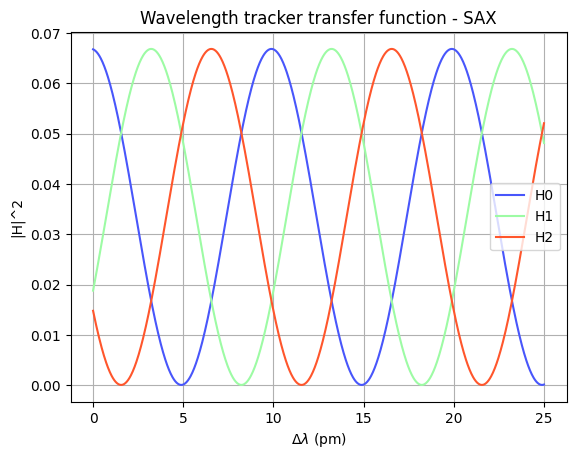

In [6]:
wls = jnp.linspace(1.55000, 1.550025, 1000)
loss_soi_dB_cm = 1
loss_soi = loss_soi_dB_cm / 10000  # dB/um

l_short = 3000
delta_l = 121726.66735519293
l_large = l_short + delta_l

test = wvltracker(wl = wls, 
                  wvg_u={"wl":wls, "length": l_short, "loss":loss_soi},
                  wvg_d={"wl":wls, "length": l_large, "loss":loss_soi},)

h0 = test["in0", "out0"]
h1 = test["in0", "out1"]
h2 = test["in0", "out2"]

H0 = np.abs(h0)**2
H1 = np.abs(h1)**2
H2 = np.abs(h2)**2

wl0 = 1.55
dl_pm = (np.asarray(wls) - wl0) * 1e6  # um -> pm

plt.plot(dl_pm, H0, linestyle = '-', color = color[1], label = 'H0')
plt.plot(dl_pm, H1, linestyle = '-', color = color[5], label = 'H1')
plt.plot(dl_pm, H2, linestyle = '-', color = color[8], label = 'H2')
plt.xlabel("$\Delta \lambda$ (pm)")
plt.ylabel('|H|^2')
plt.title('Wavelength tracker transfer function - SAX')
plt.legend()
plt.grid(True)

plt.show()

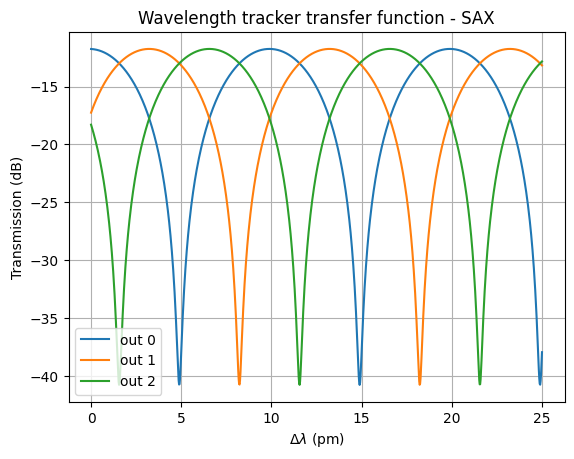

In [7]:
eps = 1e-15

H0_dB = 10 * np.log10(H0 + eps)
H1_dB = 10 * np.log10(H1 + eps)
H2_dB = 10 * np.log10(H2 + eps)


plt.plot(dl_pm, H0_dB, label="out 0")
plt.plot(dl_pm, H1_dB, label="out 1")
plt.plot(dl_pm, H2_dB, label="out 2")

plt.xlabel(r"$\Delta\lambda$ (pm)")
plt.ylabel("Transmission (dB)")
plt.title("Wavelength tracker transfer function - SAX")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
from scipy.signal import find_peaks

peaks, _ = find_peaks(H0)

peak_wls = np.asarray(wls)[peaks]
fsrs_pm = np.diff(peak_wls) * 1e6

print("FSR medio [pm]:", np.mean(fsrs_pm))
print("FSR std [pm]:", np.std(fsrs_pm))

FSR medio [pm]: 10.010010009997572
FSR std [pm]: 0.0
